# Churchland results — Figure 4, Table 1 and supplementary results

Run all cells to regenerate the current Churchland figures and tables under `outputs/paper/`. Prepared data are local; frozen representations are read from Ceph (see README). The notebook recomputes association scores and verifies balanced-accuracy decoding before plotting. Every regenerated score uses measured data; differences from the frozen manuscript values are reported without changing the paper. Retired PCA/NMF, extra-seed and candidate-count analyses are excluded.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'experiments').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from IPython.display import display, Image
from experiments.churchland import paper_results as report

## Recompute scores and check the saved decoder predictions

In [2]:
verification = report.verify()
display(verification)

{'association': [{'feature': 'recent_braking',
   'method': 'nldisco',
   'selector': 'illustrative',
   'latent': 83,
   'measured': [0.570820150888294,
    0.9532262334369035,
    0.9242645284524228,
    0.7686532789066456],
   'displayed': ['0.6708', '0.9532', '0.924', '0.868']},
  {'feature': 'recent_braking',
   'method': 'cebra',
   'selector': 'sel',
   'latent': 126,
   'measured': [0.6975541494280847,
    0.767426955176882,
    0.7499556552473983,
    0.8184437728019099],
   'displayed': ['0.6976', '0.7674', '0.749', '0.818']},
  {'feature': 'recent_braking',
   'method': 'cebra',
   'selector': 'auroc',
   'latent': 126,
   'measured': [0.6975541494280847,
    0.767426955176882,
    0.7499556552473983,
    0.8184437728019099],
   'displayed': ['0.6976', '0.7674', '0.749', '0.818']},
  {'feature': 'recent_braking',
   'method': 'langevinflow',
   'selector': 'sel',
   'latent': 136,
   'measured': [0.9088586030664395,
    0.8158169734293795,
    0.8314949572124003,
    0.90866

## Regenerate Figure 4, Tables 1/S2 and Figures S12–S15

Table maxima, including ties, are bolded automatically. Figure S14 uses the saved encoder-attribution arrays, not conditional mean activity. Figure S15 uses all fifteen measured common-H100 fits; models are not retrained.

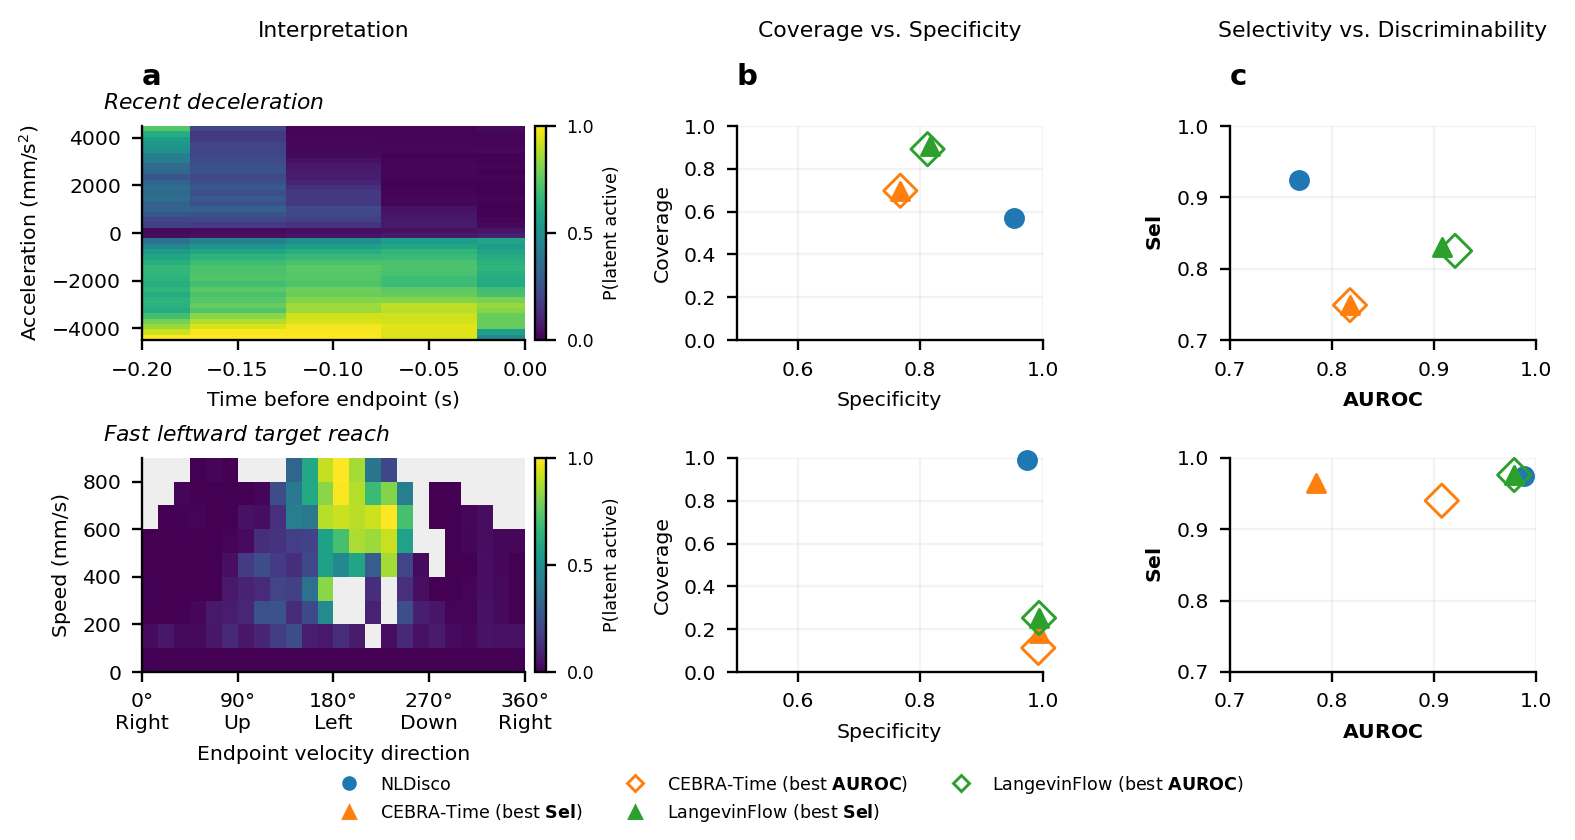

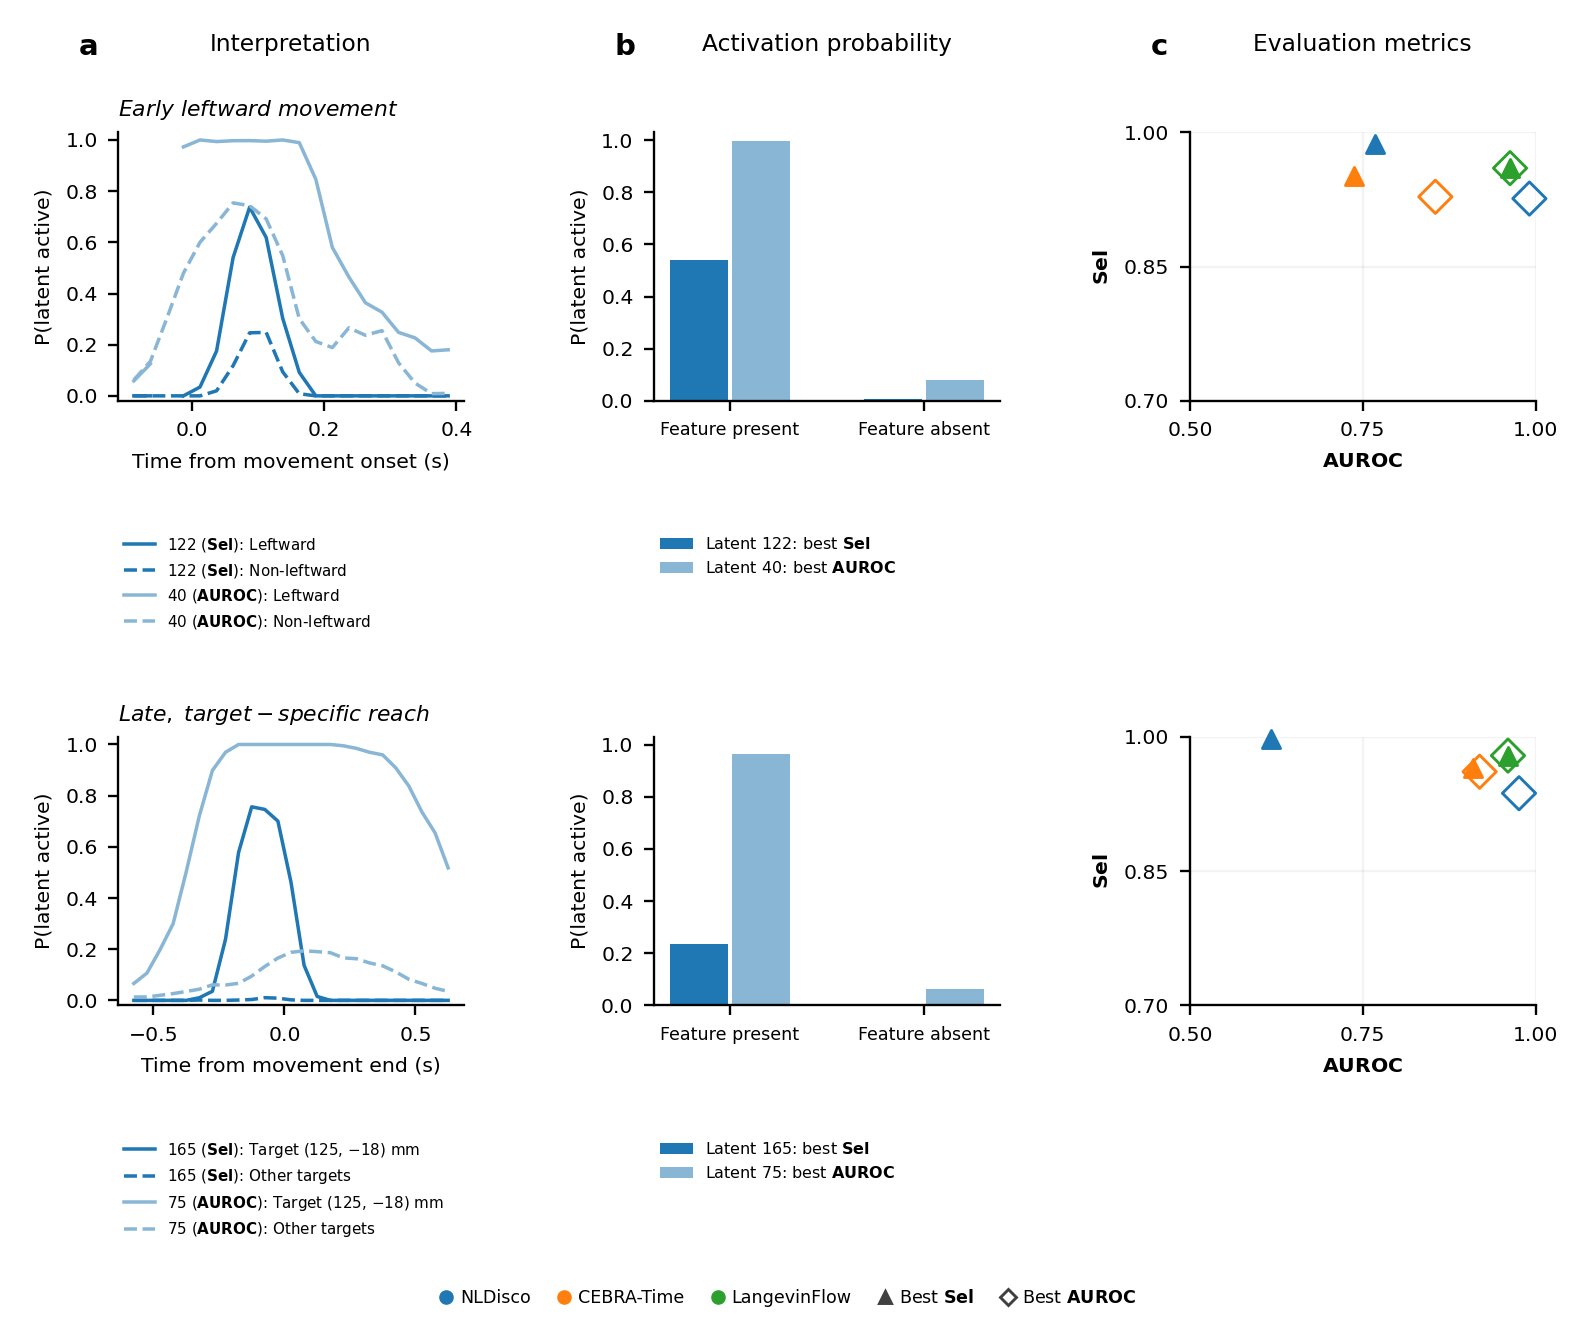

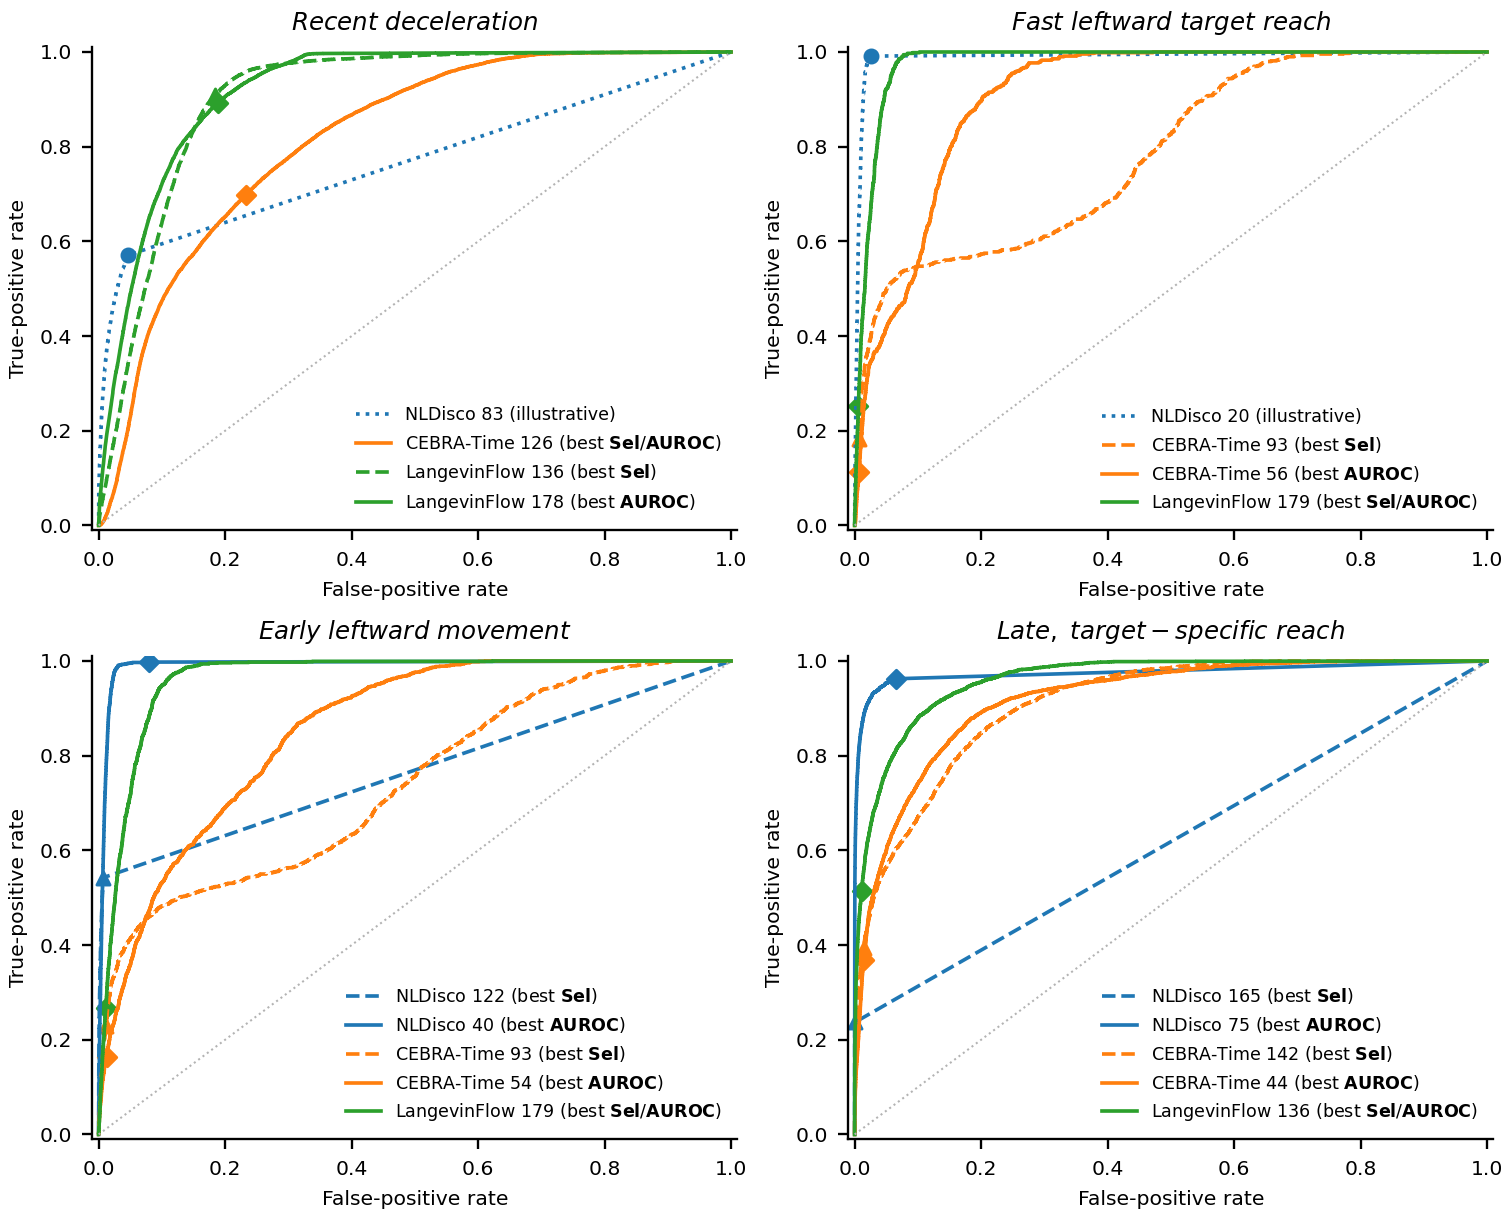

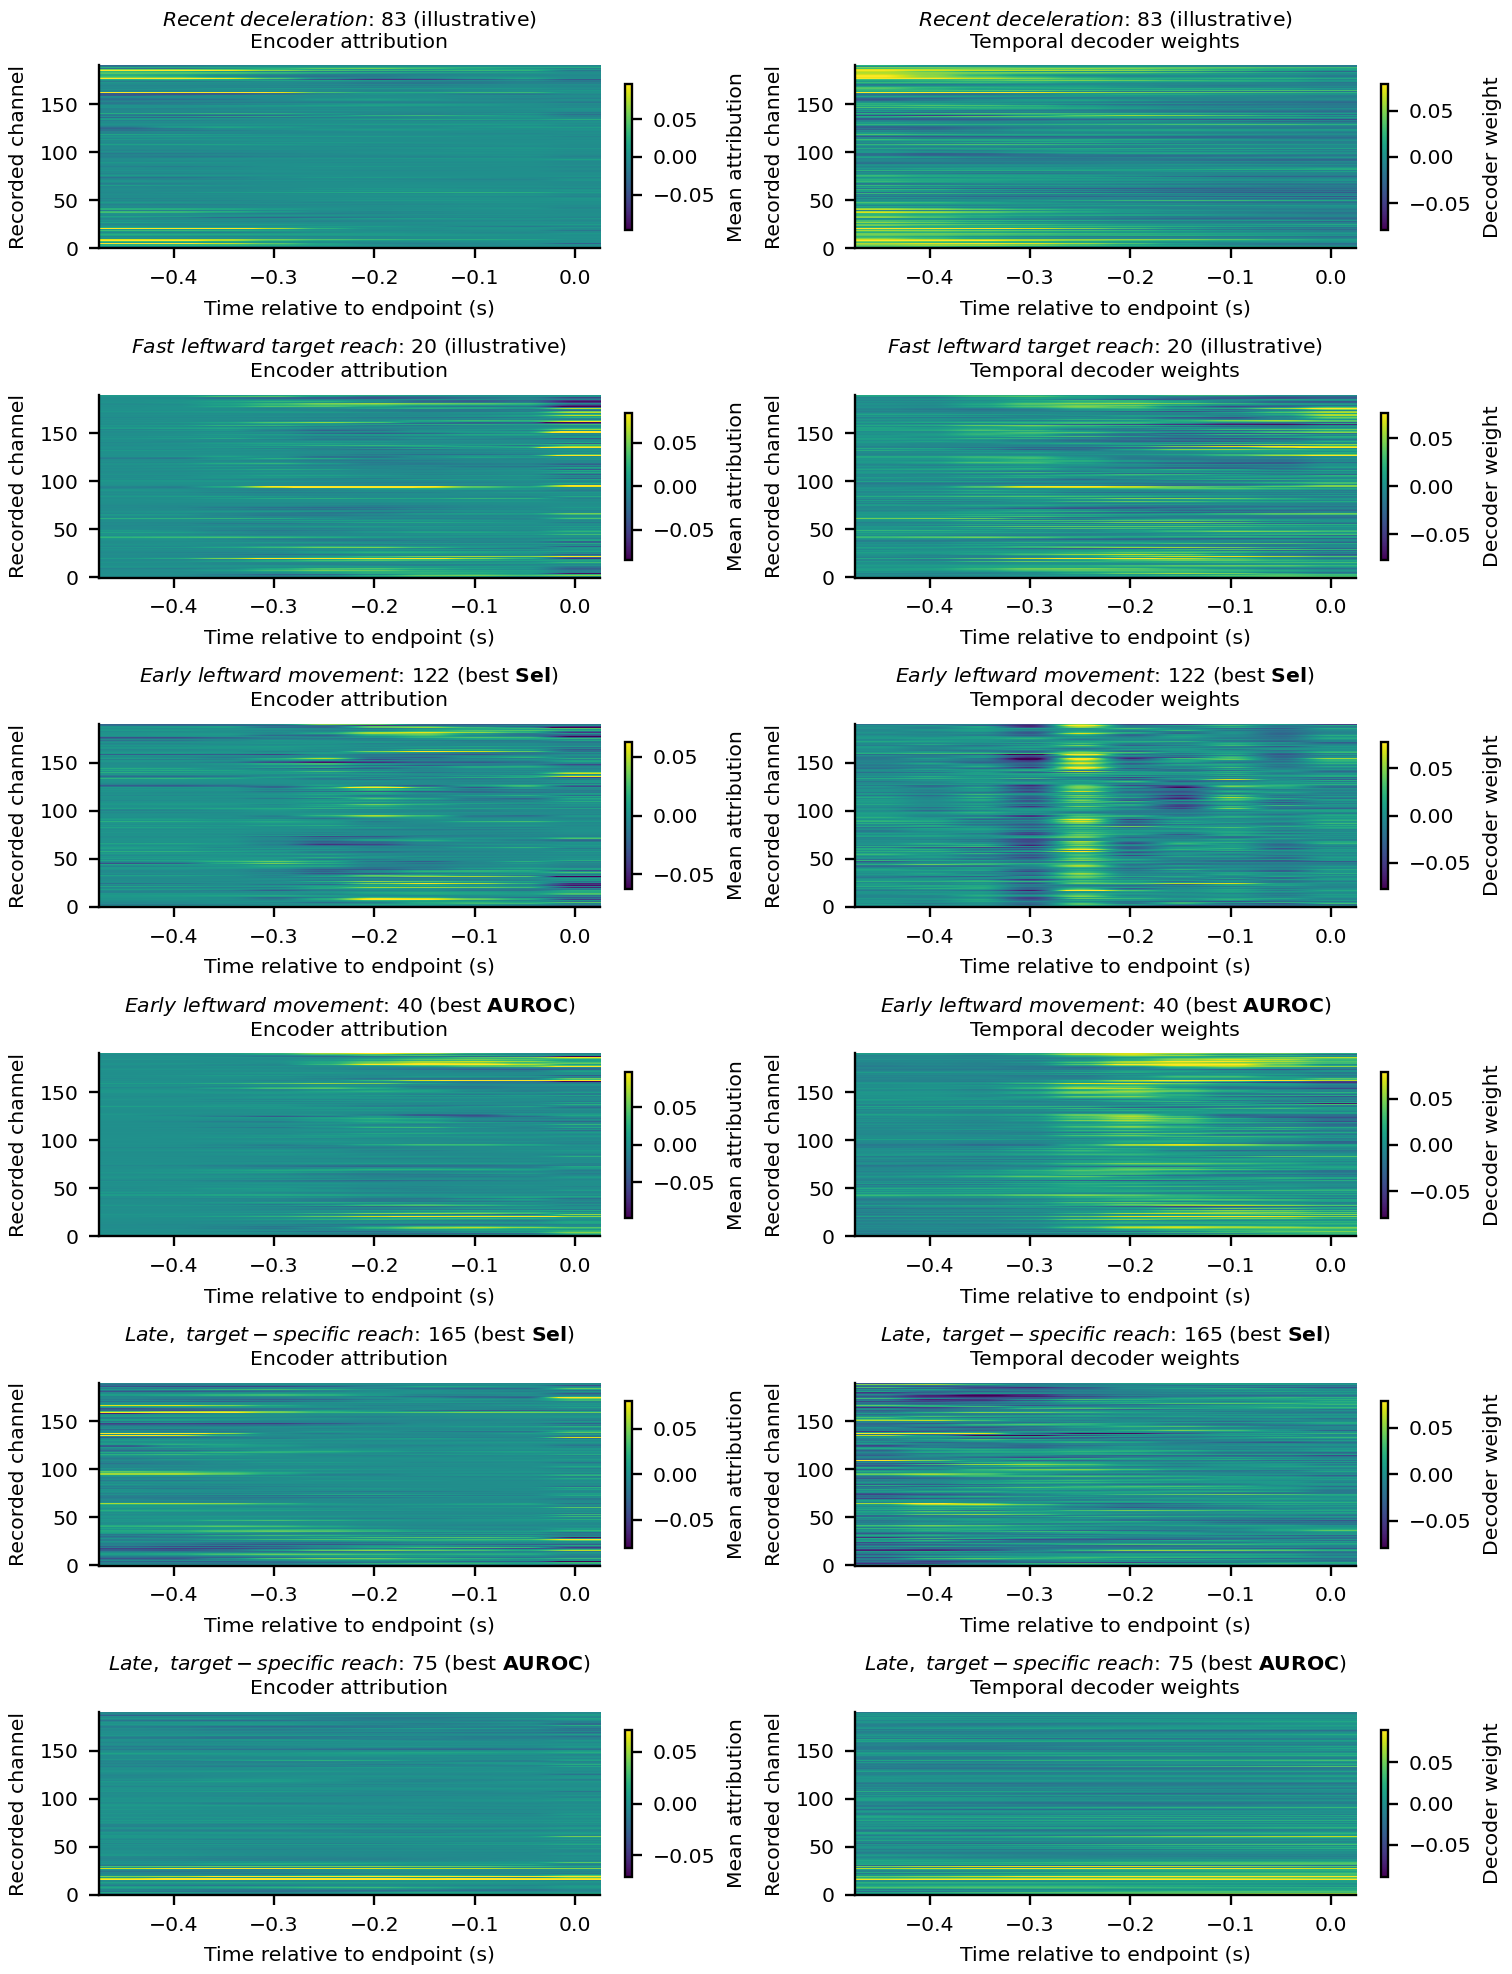

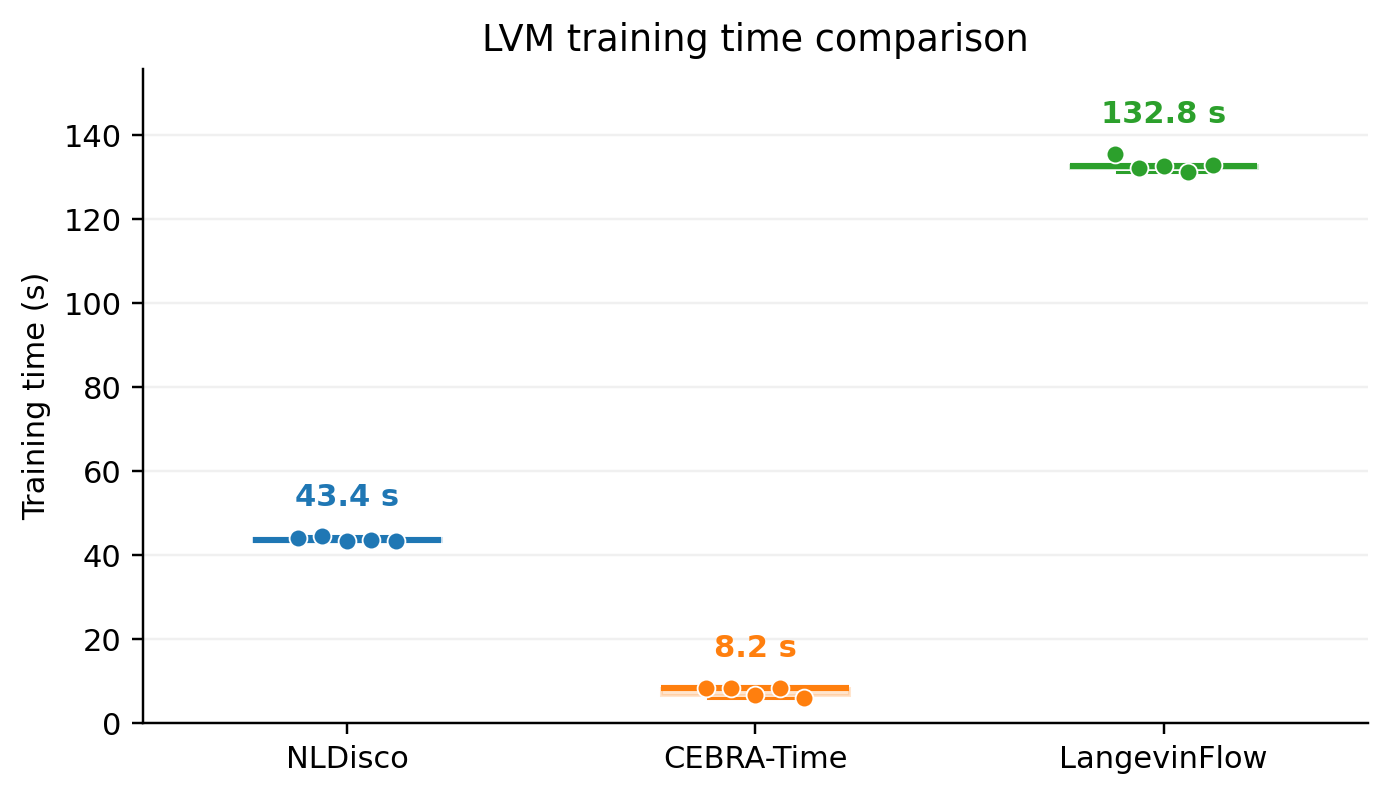

In [3]:
report.main()
for name in ("figure4", "churchland_additional_features", "churchland_feature_rocs", "churchland_traceback", "training_time_h100"):
    display(Image(filename=str(report.FIGURES / f"{name}.png")))

## Tables and measured-versus-displayed provenance

In [4]:
import pandas as pd
display(pd.DataFrame(verification["association"]))
for name in ("churchland_comparison_main", "churchland_feature_metrics"):
    print((report.FIGURES / f"{name}.tex").read_text())

,feature,method,selector,latent,measured,displayed
0,recent_braking,nldisco,illustrative,83,"[0.570820150888294, 0.9532262334369035, 0.9242...","[0.6708, 0.9532, 0.924, 0.868]"
1,recent_braking,cebra,sel,126,"[0.6975541494280847, 0.767426955176882, 0.7499...","[0.6976, 0.7674, 0.749, 0.818]"
2,recent_braking,cebra,auroc,126,"[0.6975541494280847, 0.767426955176882, 0.7499...","[0.6976, 0.7674, 0.749, 0.818]"
3,recent_braking,langevinflow,sel,136,"[0.9088586030664395, 0.8158169734293795, 0.831...","[0.9089, 0.8158, 0.831, 0.908]"
4,recent_braking,langevinflow,auroc,178,"[0.8917619858846435, 0.8119017430438478, 0.825...","[0.8918, 0.8119, 0.825, 0.921]"
5,fast_target_specific,nldisco,illustrative,20,"[0.9913544668587896, 0.9748380240649961, 0.975...","[0.9914, 0.9748, 0.975, 0.989]"
6,fast_target_specific,cebra,sel,93,"[0.1829971181556196, 0.9934524013575126, 0.965...","[0.1830, 0.9935, 0.965, 0.785]"
7,fast_target_specific,cebra,auroc,56,"[0.11239193083573487, 0.9928924845451533, 0.94...","[0.1124, 0.9929, 0.940, 0.908]"
8,fast_target_specific,langevinflow,sel,179,"[0.2521613832853026, 0.9940008912961503, 0.976...","[0.2522, 0.9940, 0.975, 0.979]"
9,fast_target_specific,langevinflow,auroc,179,"[0.2521613832853026, 0.9940008912961503, 0.976...","[0.2522, 0.9940, 0.975, 0.979]"


\begin{tabular}{l*{12}{r}}
\toprule
 & \multicolumn{6}{c}{\textit{Recent deceleration}} & \multicolumn{6}{c}{\textit{Fast leftward target reach}} \\
\cmidrule(lr){2-7}\cmidrule(lr){8-13}
Method & \metric{Cov} & \metric{Spec} & \metric{Sel} & \metric{AUROC} & \shortstack{Single\\Decode} & \shortstack{All\\Decode} & \metric{Cov} & \metric{Spec} & \metric{Sel} & \metric{AUROC} & \shortstack{Single\\Decode} & \shortstack{All\\Decode} \\
\midrule
NLDisco & 0.5708 & \textbf{0.9532} & \textbf{0.924} & 0.768 & 0.7682 & \textbf{0.9176} & \textbf{0.9914} & 0.9748 & 0.975 & \textbf{0.989} & \textbf{0.9814} & \textbf{0.9946} \\
CEBRA-Time (best \metric{Sel}) & 0.6976 & 0.7674 & 0.749 & 0.818 & 0.7291 & 0.8995 & 0.1830 & 0.9935 & 0.965 & 0.785 & 0.7184 & 0.9890 \\
CEBRA-Time (best \metric{AUROC}) & 0.6976 & 0.7674 & 0.749 & 0.818 & 0.7291 & 0.8995 & 0.1124 & 0.9929 & 0.940 & 0.908 & 0.8268 & 0.9890 \\
LangevinFlow (best \metric{Sel}) & \textbf{0.9089} & 0.8158 & 0.831 & 0.908 & \textbf{0.8620} & 0.